In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("Pharma_Industry (1).csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (500, 6)

First 5 Rows:
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeI

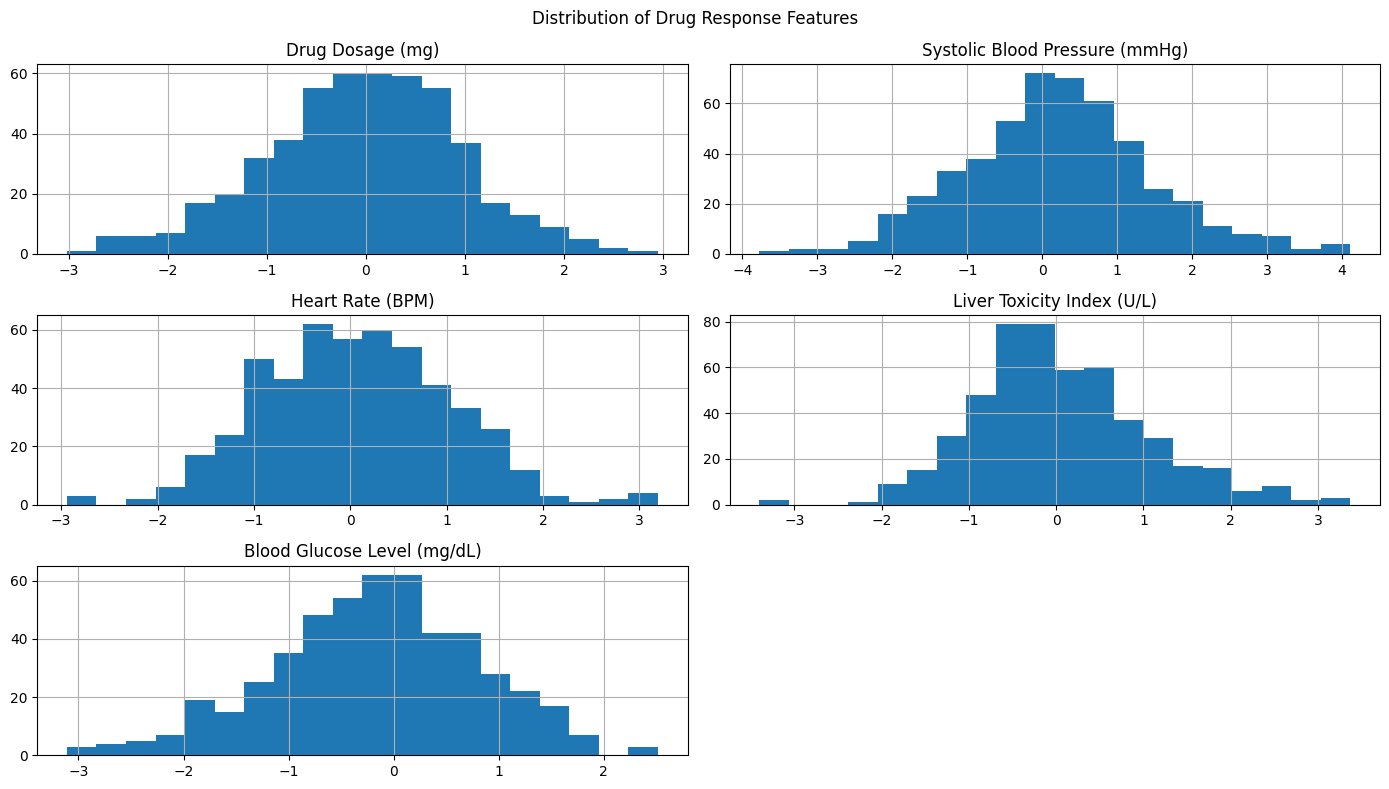

In [48]:
#EDA Visualizations & Correlation
features = [
    'Drug Dosage (mg)',
    'Systolic Blood Pressure (mmHg)',
    'Heart Rate (BPM)',
    'Liver Toxicity Index (U/L)',
    'Blood Glucose Level (mg/dL)'
]

df[features].hist(
    figsize=(14, 8),
    bins=20
)

plt.suptitle("Distribution of Drug Response Features")
plt.tight_layout()
plt.show()

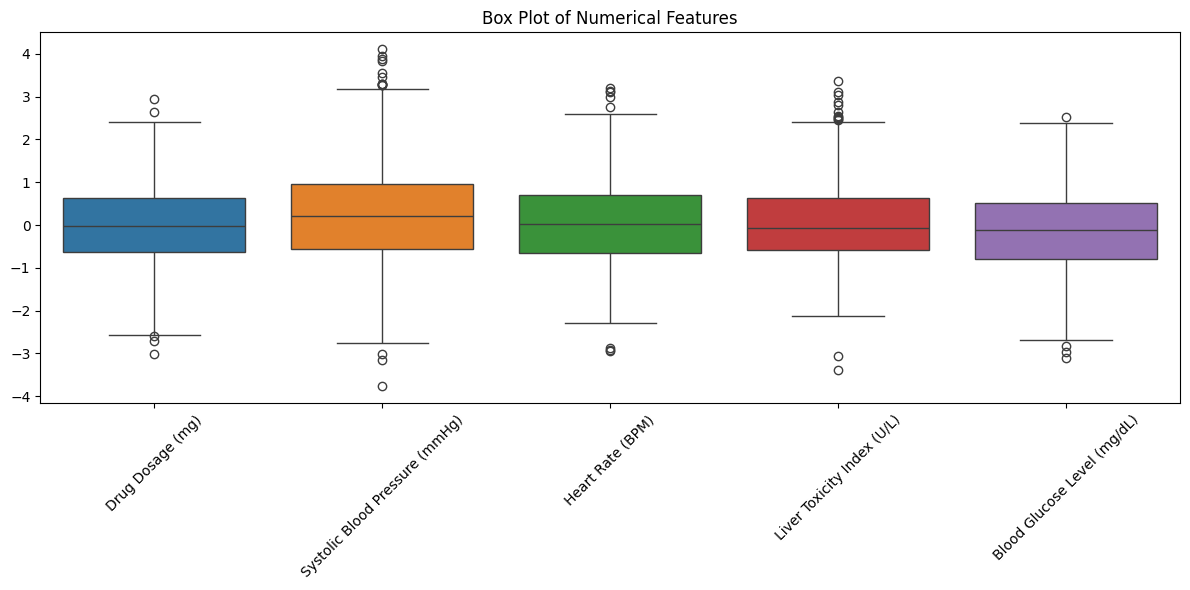

In [49]:
#box plot
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[features])

plt.title("Box Plot of Numerical Features")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

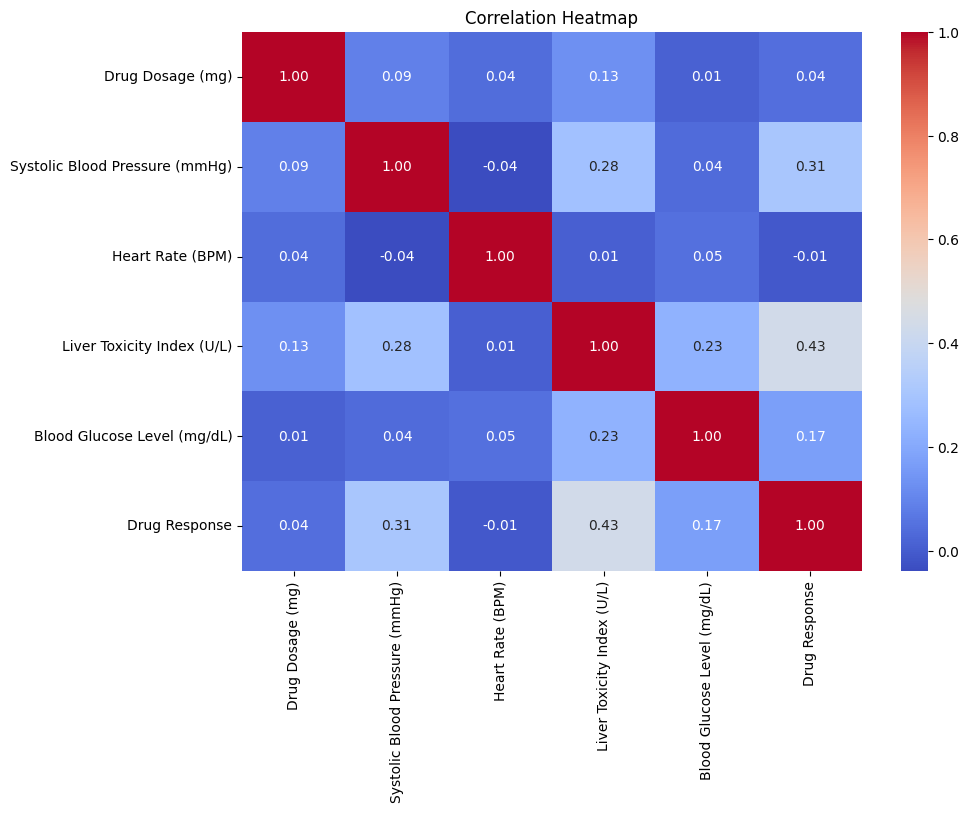

In [50]:
#correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### EDA Findings

The dataset contains five numerical predictor variables and one binary target
variable. Histograms and box plots were used to understand the distributions
and identify potential unusual observations.

The correlation heatmap shows the relationships between the numerical
features and the Drug Response target. These relationships help understand
which features may contain useful information for classification.

Features:
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  
0                    0.258286                    -0.792011  
1                    2.866786                    -0.719447  
2                   -0.325370                     0.191314  
3                    0.975286                    -0.823355  
4                    1.896015                    -0.960130  

Target:
0    1
1    1
2    0
3    1
4    1
Name: Drug Response, dtype: int64

Class Distribution:
Drug Response
1    260
0    240
Name: count, dtype: int64
Training Shape: (400, 5)
Tes

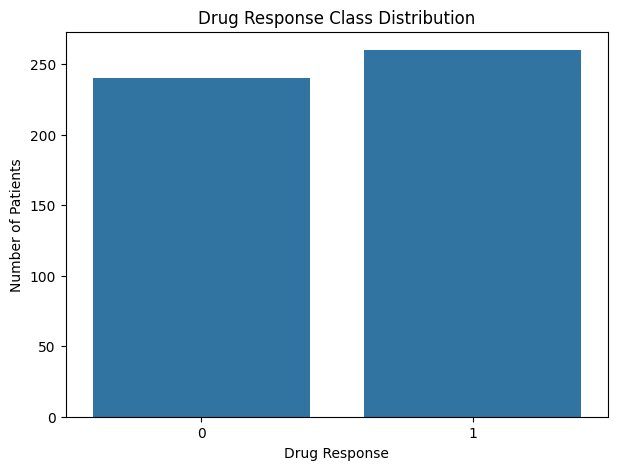

Class Distribution:
Drug Response
1    260
0    240
Name: count, dtype: int64


In [54]:
#Task 2
X = df[features]

y = df['Drug Response']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nClass Distribution:")
print(y.value_counts())

#split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

#Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

#task3
plt.figure(figsize=(7, 5))

sns.countplot(
    x='Drug Response',
    data=df
)

plt.title("Drug Response Class Distribution")
plt.xlabel("Drug Response")
plt.ylabel("Number of Patients")

plt.show()

print("Class Distribution:")
print(df['Drug Response'].value_counts())

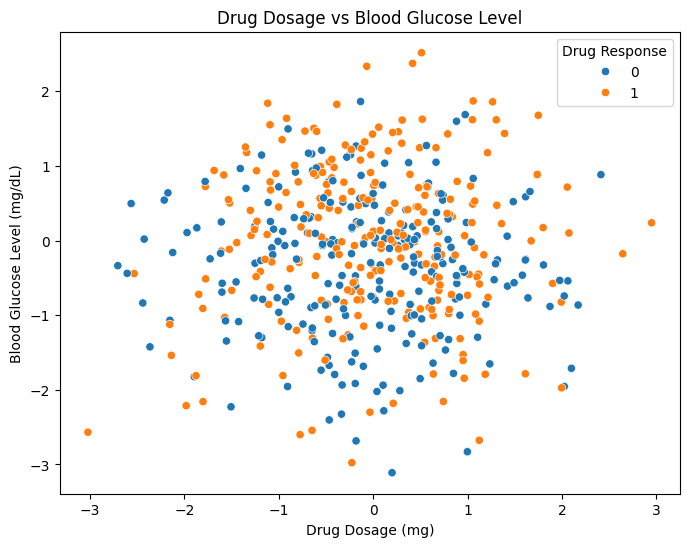

In [55]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Drug Dosage (mg)',
    y='Blood Glucose Level (mg/dL)',
    hue='Drug Response'
)

plt.title("Drug Dosage vs Blood Glucose Level")
plt.show()

In [57]:
#task-4
svm_linear = SVC(
    kernel='linear',
    C=1
)

svm_linear.fit(
    X_train_scaled,
    y_train
)

y_pred = svm_linear.predict(
    X_test_scaled
)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

#metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100

Accuracy : 0.72
Precision: 0.7608695652173914
Recall   : 0.6730769230769231
F1 Score : 0.7142857142857143


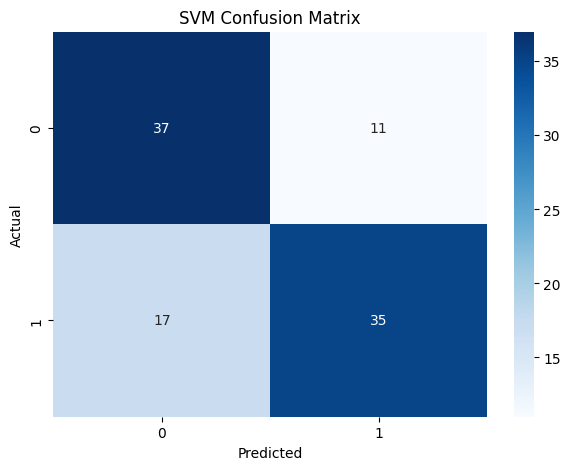

In [58]:
#task-5
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [59]:
#task-6
kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1, 10]

results = []

for kernel in kernels:

    for C in C_values:

        model = SVC(
            kernel=kernel,
            C=C
        )

        model.fit(
            X_train_scaled,
            y_train
        )

        prediction = model.predict(
            X_test_scaled
        )

        results.append({
            'Kernel': kernel,
            'C': C,
            'Accuracy': accuracy_score(y_test, prediction),
            'Precision': precision_score(y_test, prediction),
            'Recall': recall_score(y_test, prediction),
            'F1 Score': f1_score(y_test, prediction)
        })

results_df = pd.DataFrame(results)

print(results_df)

   Kernel     C  Accuracy  Precision    Recall  F1 Score
0  linear   0.1      0.72   0.760870  0.673077  0.714286
1  linear   1.0      0.72   0.760870  0.673077  0.714286
2  linear  10.0      0.72   0.760870  0.673077  0.714286
3    poly   0.1      0.68   0.727273  0.615385  0.666667
4    poly   1.0      0.65   0.666667  0.653846  0.660194
5    poly  10.0      0.62   0.634615  0.634615  0.634615
6     rbf   0.1      0.78   0.812500  0.750000  0.780000
7     rbf   1.0      0.77   0.754386  0.826923  0.788991
8     rbf  10.0      0.75   0.745455  0.788462  0.766355


Best SVM Configuration:
Kernel            rbf
C                 1.0
Accuracy         0.77
Precision    0.754386
Recall       0.826923
F1 Score     0.788991
Name: 7, dtype: object


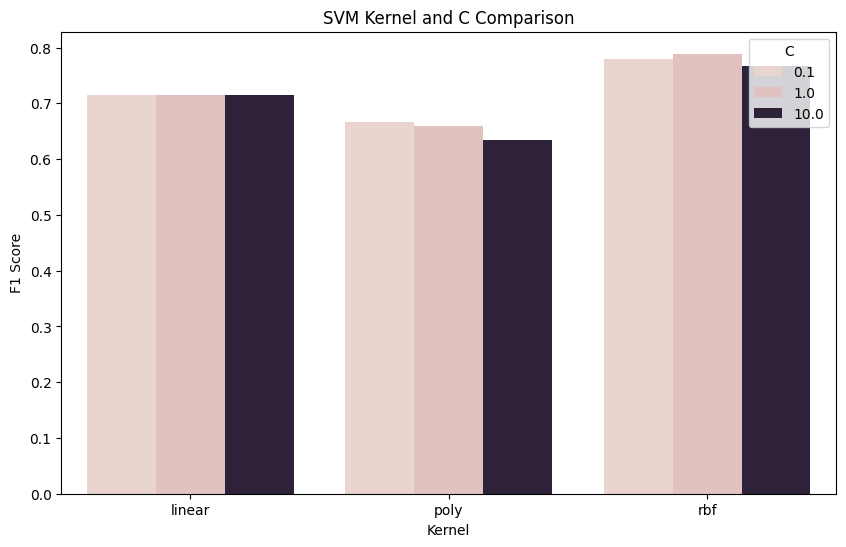

In [61]:
#best model finding
best_model = results_df.loc[
    results_df['F1 Score'].idxmax()
]

print("Best SVM Configuration:")
print(best_model)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Kernel',
    y='F1 Score',
    hue='C'
)

plt.title("SVM Kernel and C Comparison")

plt.show()

## Task 7: Comparison and Analysis

### Linear Kernel

The Linear kernel creates a linear decision boundary between the classes. It
is computationally efficient and works well when the classes are approximately
linearly separable.

### Polynomial Kernel

The Polynomial kernel can model non-linear relationships between the features.
It can provide more flexible decision boundaries but may require additional
parameter tuning.

### RBF Kernel

The RBF kernel can model complex non-linear relationships and is useful when
the classes cannot be effectively separated using a linear boundary.

### SVM Strengths

- Effective for classification problems.
- Works well with numerical features.
- Can model both linear and non-linear relationships.
- RBF can capture complex decision boundaries.
- Effective when the number of features is relatively high.

### SVM Weaknesses

- Sensitive to feature scaling.
- Hyperparameters require tuning.
- Can become computationally expensive for very large datasets.
- The resulting model is less interpretable than some simpler models.

### Practical Implications

SVM can be used to classify patients according to their predicted drug
response. Such models could potentially assist pharmaceutical researchers in
identifying patterns associated with positive drug responses.

However, machine learning predictions should be validated using clinical
research and should not independently replace medical or clinical decisions.

# **Final Conclusion**

The Pharma Industry dataset was analyzed using Exploratory Data Analysis,
including statistical summaries, histograms, box plots, scatter plots, and a
correlation heatmap.

The dataset contained five numerical predictor variables and one binary target
variable representing drug response. Since all predictor variables were
numerical, categorical encoding was not required.

The data was divided into training and testing sets using an 80:20 ratio.
StandardScaler was applied because SVM models are sensitive to differences in
feature scales.

A Support Vector Machine classifier was implemented using a linear kernel and
evaluated using accuracy, precision, recall, and F1-score.

Different SVM kernels, including Linear, Polynomial, and RBF, were then
compared using different values of the regularization parameter C.

The comparison helps identify the SVM configuration that provides the best
classification performance for this dataset.

Overall, SVM provides an effective approach for classifying drug response based
on patient and biological measurements. Further validation and clinical
evaluation would be necessary before using such a model in real-world
pharmaceutical decision-making.